In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from datetime import datetime

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy import visualization as aviz
from astropy.visualization.wcsaxes import WCSAxes
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from photutils.aperture import CircularAperture

import sso_query
from importlib import reload 
sso_query = reload(sso_query)

from sso_query.query_images import build_query, make_query, download_data, get_image_cutout, display_image, diaSource_query

In [5]:
diaSourceId = 600447721060958225

In [6]:
results = diaSource_query(diaSourceId)
results

Executing the following query:
SELECT ra,dec,visit,detector FROM dp1.DiaSource
WHERE diaSourceId=600447721060958225
Job phase is COMPLETED
Found 1 results


ra,dec,visit,detector
deg,deg,,
float64,float64,int64,int64
37.399004332724274,6.970726849074913,2024120700172,1


In [7]:
dia_dict = results.to_pandas().iloc[0].to_dict()
dia_dict

{'ra': 37.399004332724274,
 'dec': 6.970726849074913,
 'visit': 2024120700172.0,
 'detector': 1.0}

In [8]:
cutout_center = SkyCoord(dia_dict["ra"], dia_dict["dec"], unit='deg', frame='icrs')
cutout_center

<SkyCoord (ICRS): (ra, dec) in deg
    (37.39900433, 6.97072685)>

In [9]:
# query = build_query2(center, t_min=time1, t_max=time2)
query = build_query(visit = dia_dict["visit"], detector =  dia_dict["detector"], calib_level = 3)
print(query)

SELECT lsst_visit, lsst_detector, lsst_tract, lsst_patch, lsst_band,s_ra, s_dec, t_min, t_max, s_region, access_url
FROM ivoa.ObsCore
WHERE calib_level = 3
AND lsst_visit=2024120700172.0 AND lsst_detector=1.0



In [10]:
# results = make_query(center, t_min=time1, t_max=time2)
results = make_query(visit = dia_dict["visit"], detector =  dia_dict["detector"], calib_level = 3)

Executing the following query:
SELECT lsst_visit, lsst_detector, lsst_tract, lsst_patch, lsst_band,s_ra, s_dec, t_min, t_max, s_region, access_url
FROM ivoa.ObsCore
WHERE calib_level = 3
AND lsst_visit=2024120700172.0 AND lsst_detector=1.0

Job phase is COMPLETED
Found 1 results


In [11]:
results

lsst_visit,lsst_detector,lsst_tract,lsst_patch,lsst_band,s_ra,s_dec,t_min,t_max,s_region,access_url
,,,,,deg,deg,d,d,,
int64,int64,int64,int64,object,float64,float64,float64,float64,object,object
2024120700172,1,--,--,g,37.49091502690746,6.914784383599781,60652.09033858777,60652.09069085648,POLYGON ICRS 37.610612 7.020169 37.382643 7.031702 37.371302 6.809361 37.599100 6.797831,https://data.lsst.cloud/api/datalink/links?ID=ivo%3A%2F%2Forg.rubinobs%2Flsst-dp1%3Frepo%3Ddp1%26id%3Dd36f7ef8-3179-4009-a025-dfeb7da75e9a


In [12]:
hdulist = get_image_cutout(results[0], cutout_center, 20*u.arcsec)
print(hdulist.info())

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     728   ()      
  1  IMAGE         1 ImageHDU       123   (200, 200)   float32   
  2  MASK          1 ImageHDU       143   (200, 200)   int32   
  3  VARIANCE      1 ImageHDU       123   (200, 200)   float32   
  4  ARCHIVE_INDEX    1 BinTableHDU     41   91R x 7C   [1J, 1J, 1J, 1J, 1J, 64A, 64A]   
  5  FilterLabel    1 BinTableHDU     28   1R x 3C   [2X, 32A, 32A]   
  6  Detector      1 BinTableHDU    115   1R x 22C   [1QA(7), 1J, 1J, 1QA(13), 1J, 1J, 1J, 1J, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1QE(0), 1QA(3), 1J]   
  7  TransformMap    1 BinTableHDU     33   19R x 5C   [1QA(10), 1QA(7), 1QA(10), 1QA(7), 1J]   
  8  ExposureSummaryStats    1 BinTableHDU     19   21R x 1C   [1QB(101941)]   
  9  Detector      2 BinTableHDU    201   16R x 38C   [3X, 1QA(3), 1J, 1J, 1J, 1J, 1D, 1D, 1D, 1D, 1J, 1QD(2), 1QA(12), 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J,

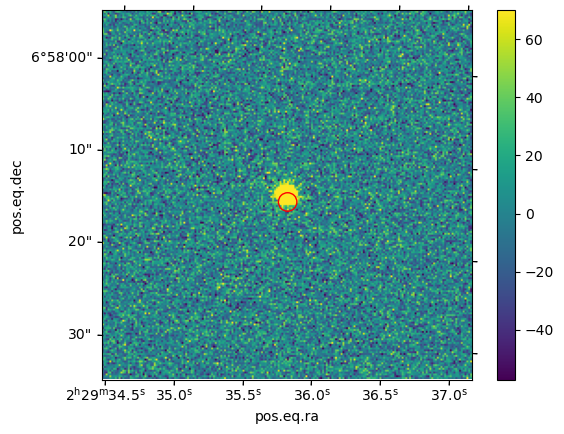

In [13]:
ihdu = 1
img = hdulist[ihdu].data
hdr = hdulist[ihdu].header
wcs = WCS(hdr)

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0], projection = wcs)


norm = aviz.ImageNormalize(img, interval=aviz.ZScaleInterval())
s1 = ax1.imshow(img, norm=norm, origin="lower")
cbar = plt.colorbar(s1)


# plot target coords as apertures
pos = skycoord_to_pixel(cutout_center, wcs)
aperture = CircularAperture(positions = np.array(pos),
                       r = 5)
aperture.plot(color="r")

plt.show()